In [1]:
from qiskit.circuit.library import StatePreparation, TwoLocal
from qiskit.circuit.random import random_circuit
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, SparsePauliOp
from qiskit.primitives import StatevectorEstimator
import pickle
import numpy as np
from scipy.optimize import minimize

In [2]:
def energy_cost(
    qc: QuantumCircuit,
    parameters: list[float],
    H: SparsePauliOp,
    estim: StatevectorEstimator
) -> float:
    '''Evaluate fidelity of variational ansatz with target ground state'''

    res = estim.run([(qc.assign_parameters(parameters), H)])

    return res.result()[0].data.evs

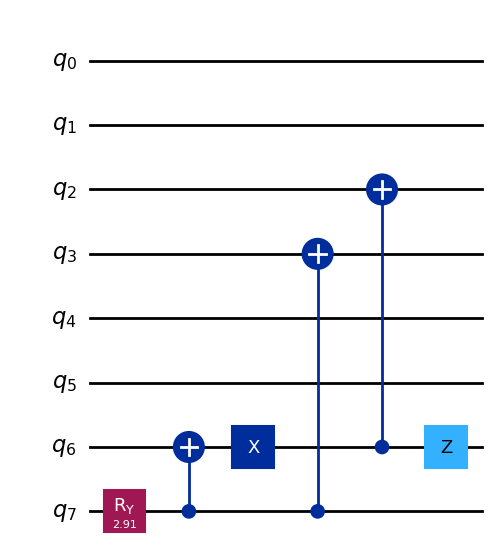

In [3]:
test = QuantumCircuit(8)
test.ry(2 * np.arccos(0.11800159),7)
test.cx(7, 6)
test.x(6)
test.cx(7,3)
test.cx(6,2)
test.z(6)
test.draw('mpl')

In [150]:
def qc_new_cost(theta):
    qc_new = QuantumCircuit(8)
    qc_new.x(7)
    for i in range(3):
        qc_new.cry(theta[i], 7-i, 6-i)
        qc_new.cx(6-i, 7-i)
    qc_new.draw()
    qc_new.cx(7,3)
    qc_new.cx(6, 2)
    qc_new.cx(5, 1)
    qc_new.cx(4, 2)
    qc_new.draw()
    return estim.run([(qc_new, H)]).result()[0].data.evs

initial_params = 2 * np.pi * np.random.rand(3)
res = minimize(qc_new_cost, initial_params, method = 'COBYLA', bounds = [(0, 2*np.pi)] *3, options = {'maxiter': 10000})

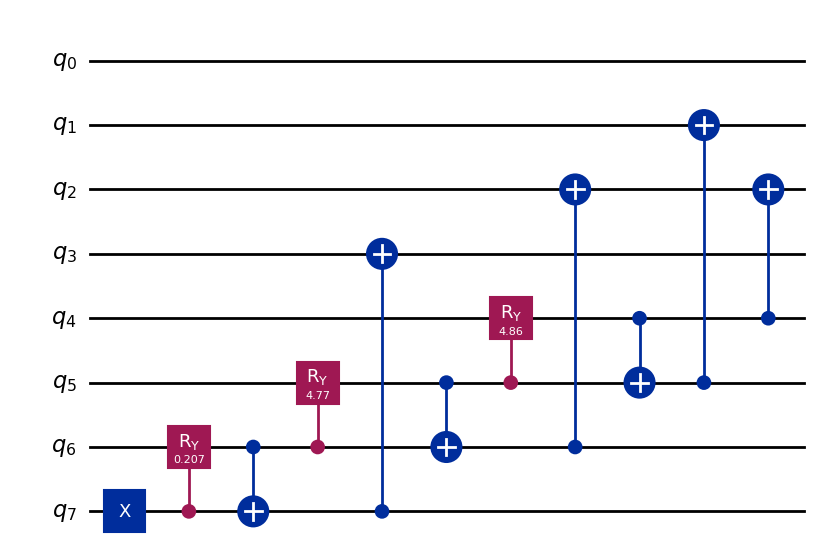

In [152]:
theta = res.x
qc_new = QuantumCircuit(8)
qc_new.x(7)
for i in range(3):
    qc_new.cry(theta[i], 7-i, 6-i)
    qc_new.cx(6-i, 7-i)
qc_new.draw()
qc_new.cx(7,3)
qc_new.cx(6, 2)
qc_new.cx(5, 1)
qc_new.cx(4, 2)
qc_new.draw('mpl')

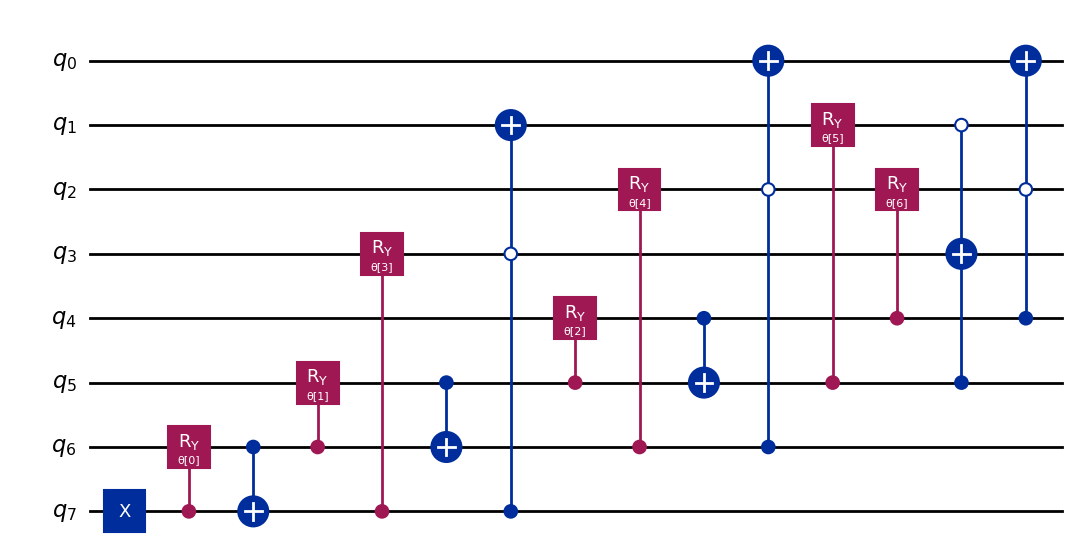

In [162]:
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import RYGate
theta = ParameterVector('θ', 7)
qc_new = QuantumCircuit(8)
qc_new.x(7)
for i in range(3):
    qc_new.cry(theta[i], 7-i, 6-i)
    qc_new.cx(6-i, 7-i)
qc_new.draw()
#qc_new.cx(7,3)
#qc_new.cx(6, 2)
#qc_new.cx(5, 1)
#qc_new.cx(4, 2)
qc_new.cry(theta[3], 7, 3)
qc_new.ccx(7, 3, 1, ctrl_state = '01')
qc_new.cry(theta[4], 6, 2)
qc_new.ccx(6, 2, 0, ctrl_state = '01')
qc_new.cry(theta[5], 5, 1)
qc_new.ccx(5, 1, 3, ctrl_state = '01')
qc_new.cry(theta[6], 4, 2)
qc_new.ccx(4, 2, 0,ctrl_state = '01')
qc_new.draw('mpl')

In [ ]:
sv_estim = StatevectorEstimator()
def qc_new_cost_2(thetas):
    res = sv_estim.run([(qc_new.assign_parameters(thetas), H)])
    return res.result()[0].data.evs
initial_params = 2 * np.pi * np.random.rand(7)
res = minimize(qc_new_cost_2, initial_params, method = 'COBYLA', bounds = [(0, 2*np.pi)] * 7, options = {'maxiter': 20000})
    

In [5]:
import json
with open('data/training_hyperparameters_square_U2.json', 'r') as f:
    data = json.load(f)

In [18]:
Ham = SparsePauliOp(data['gfn_config']['quantum']['pauli_str_list'], data['gfn_config']['quantum']['w_list'])
Ham

SparsePauliOp(['IIIIIYZY', 'IIIIIXZX', 'IIIYZZZY', 'IIIXZZZX', 'IYZYIIII', 'IXZXIIII', 'IYZZZYII', 'IXZZZXII', 'IIIIYZYI', 'IIIIXZXI', 'IIYZZZYI', 'IIXZZZXI', 'YZYIIIII', 'XZXIIIII', 'YZZZYIII', 'XZZZXIII', 'IIIIIIZI', 'IIIIIIIZ', 'IIIIIIZZ', 'IIIIZIII', 'IIIIIZII', 'IIIIZZII', 'IIZIIIII', 'IIIZIIII', 'IIZZIIII', 'ZIIIIIII', 'IZIIIIII', 'ZZIIIIII'],
              coeffs=[-0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j,
 -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j,
 -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j,  0.5+0.j, -0.5+0.j, -0.5+0.j,
  0.5+0.j, -0.5+0.j, -0.5+0.j,  0.5+0.j, -0.5+0.j, -0.5+0.j,  0.5+0.j])

In [15]:
e, v = np.linalg.eig(Ham.to_matrix())

In [19]:
e[np.argmin(e)]

(-5.627213005296671-3.944304526105059e-31j)

In [20]:
v[:,2]

array([ 0.00000000e+000+0.00000000e+000j,
       -1.66714163e-016-3.54160076e-032j,
        4.93628532e-016+6.77944348e-032j,
       -1.84239949e-001+2.46519033e-032j,
       -1.83146047e-016+3.35106160e-033j,
       -2.14110662e-017+8.43899940e-034j,
        2.59189359e-001-2.46519033e-032j,
        4.17310966e-017+2.74360431e-038j,
        8.12578710e-016+6.27980991e-032j,
       -2.59189359e-001+0.00000000e+000j,
       -2.35058913e-017+3.77967418e-045j,
       -2.15644783e-018+4.96401919e-039j,
       -1.84239949e-001+0.00000000e+000j,
       -3.69994520e-018-2.72708485e-038j,
        2.66760975e-018-4.92946186e-039j,
       -1.19618951e-032+1.81620480e-048j,
       -6.73281999e-016-3.51526174e-032j,
        2.92159821e-032-6.19773086e-050j,
        2.59189359e-001-2.46519033e-032j,
       -5.54278201e-019-3.01633198e-039j,
       -3.67676650e-018+1.84331806e-033j,
       -4.05173174e-034+4.13212738e-052j,
        5.37240150e-018+4.38691171e-038j,
       -9.84553776e-036+1.39993964

In [62]:
from qiskit.circuit.library import real_amplitudes
qc = real_amplitudes(8, entanglement= 'reverse_linear', reps = 2)

In [49]:
qc.num_parameters

24

In [63]:
qc.decompose().draw()

┌─────────────┐                                                     »
q_0: ┤ R(θ[0],π/2) ├─────────────────────────────────────────────────────»
     ├─────────────┤                                                     »
q_1: ┤ R(θ[1],π/2) ├─────────────────────────────────────────────────────»
     ├─────────────┤                                                     »
q_2: ┤ R(θ[2],π/2) ├─────────────────────────────────────────────────────»
     ├─────────────┤                                                     »
q_3: ┤ R(θ[3],π/2) ├────────────────────────────────────────────■────────»
     ├─────────────┤                                          ┌─┴─┐      »
q_4: ┤ R(θ[4],π/2) ├────────────────────────────■─────────────┤ X ├──────»
     ├─────────────┤                          ┌─┴─┐      ┌────┴───┴─────┐»
q_5: ┤ R(θ[5],π/2) ├────────────■─────────────┤ X ├──────┤ R(θ[13],π/2) ├»
     ├─────────────┤          ┌─┴─┐      ┌────┴───┴─────┐└──────────────┘»
q_6: ┤ R(θ[6],π/2) ├──■───────┤ X ├──────┤ R(θ[14],π/2) ├───────■────────»
     ├─────────────┤┌─┴─┐┌────┴───┴─────┐└──────────────┘     ┌─┴─┐      »
q_7: ┤ R(θ[7],π/2) ├┤ X ├┤ R(θ[15],π/2) ├─────────────────────┤ X ├──────»
     └─────────────┘└───┘└──────────────┘                     └───┘      »
«                                                     ┌─────────────┐ »
«q_0: ───────────────────────────────────────■────────┤ R(θ[8],π/2) ├─»
«                                          ┌─┴─┐      ├─────────────┤ »
«q_1: ───────────────────────■─────────────┤ X ├──────┤ R(θ[9],π/2) ├─»
«                          ┌─┴─┐      ┌────┴───┴─────┐└─────────────┘ »
«q_2: ───────■─────────────┤ X ├──────┤ R(θ[10],π/2) ├───────■────────»
«          ┌─┴─┐      ┌────┴───┴─────┐└──────────────┘     ┌─┴─┐      »
«q_3: ─────┤ X ├──────┤ R(θ[11],π/2) ├───────■─────────────┤ X ├──────»
«     ┌────┴───┴─────┐└──────────────┘     ┌─┴─┐      ┌────┴───┴─────┐»
«q_4: ┤ R(θ[12],π/2) ├───────■─────────────┤ X ├──────┤ R(θ[20],π/2) ├»
«     └──────────────┘     ┌─┴─┐      ┌────┴───┴─────┐└──────────────┘»
«q_5: ───────■─────────────┤ X ├──────┤ R(θ[21],π/2) ├────────────────»
«          ┌─┴─┐      ┌────┴───┴─────┐└──────────────┘                »
«q_6: ─────┤ X ├──────┤ R(θ[22],π/2) ├────────────────────────────────»
«     ┌────┴───┴─────┐└──────────────┘                                »
«q_7: ┤ R(θ[23],π/2) ├────────────────────────────────────────────────»
«     └──────────────┘                                                »
«                                     ┌──────────────┐
«q_0: ───────────────────────■────────┤ R(θ[16],π/2) ├
«                          ┌─┴─┐      ├──────────────┤
«q_1: ───────■─────────────┤ X ├──────┤ R(θ[17],π/2) ├
«          ┌─┴─┐      ┌────┴───┴─────┐└──────────────┘
«q_2: ─────┤ X ├──────┤ R(θ[18],π/2) ├────────────────
«     ┌────┴───┴─────┐└──────────────┘                
«q_3: ┤ R(θ[19],π/2) ├────────────────────────────────
«     └──────────────┘                                
«q_4: ────────────────────────────────────────────────
«                                                     
«q_5: ────────────────────────────────────────────────
«                                                     
«q_6: ────────────────────────────────────────────────
«                                                     
«q_7: ────────────────────────────────────────────────
«

In [19]:
def cost(qc: QuantumCircuit, op: SparsePauliOp, params: list[float]):
    estim = StatevectorEstimator()
    res = estim.run([(qc.assign_parameters(params), op)])
    return res.result()[0].data.evs

In [57]:
n_params = qc.num_parameters
res = minimize(lambda x: cost(qc, Ham, x), np.random.rand(n_params), method = 'COBYLA', bounds = [(0, 2*np.pi)] * n_params, options = {'maxiter' : 100000})

In [58]:
res

 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -4.202672114583806
       x: [ 1.543e+00  3.242e-03 ...  3.842e-05  0.000e+00]
    nfev: 93282
   maxcv: 4.446922973085077e-21

In [32]:
qc.decompose().draw('mpl')

NameError: name 'qc' is not defined

In [59]:
import pickle

with open('hub_res.pkl', 'wb') as file:
    pickle.dump(res, file)

In [60]:
ans = Ham.paulis.group_qubit_wise_commuting()

In [85]:
len(ans)

9

In [86]:
ans

[PauliList(['IYZZZYII', 'IIIIIYZY', 'IIZZIIII', 'IIIIIIZI', 'IIIIZIII',
            'IIZIIIII', 'IIIZIIII', 'ZIIIIIII']),
 PauliList(['IXZZZXII', 'IIIIIXZX']),
 PauliList(['IIYZZZYI', 'YZYIIIII', 'IIIIZZII', 'IIIIIIIZ', 'IIIIIZII',
            'IZIIIIII']),
 PauliList(['IIXZZZXI', 'XZXIIIII']),
 PauliList(['IIIYZZZY', 'IYZYIIII']),
 PauliList(['IIIXZZZX', 'IXZXIIII']),
 PauliList(['YZZZYIII', 'IIIIYZYI']),
 PauliList(['XZZZXIII', 'IIIIXZXI']),
 PauliList(['IIIIIIZZ', 'ZZIIIIII'])]

In [89]:
loader = HamiltonianLoader()
cI, paulis, coeffs = loader.load_h2_8qubit()

In [90]:
cI

1.5253256224066558

In [92]:
coeffs

[0.08794122934165582,
 0.08794122934165582,
 -0.2724180193998683,
 -0.6921496164450819,
 -0.4043851244705001,
 -0.05255329774132767,
 -0.05255329774132767,
 -1.0346287559322498,
 -0.2724180193998682,
 0.08794122934165581,
 0.08794122934165581,
 -0.4043851244705001,
 -0.05255329774132766,
 -0.05255329774132766,
 -0.6921496164450818,
 -1.0346287559322498,
 0.023907160243420156,
 0.023907160243420156,
 -0.017318726572294618,
 -0.017318726572294618,
 -0.012608046401606652,
 -0.012608046401606652,
 -0.015412105039717084,
 -0.012794256152536574,
 -0.0026178488871805078,
 -0.0026178488871805078,
 -0.012794256152536574,
 -0.015412105039717084,
 -0.004710680170687968,
 -0.004710680170687968,
 -0.004710680170687968,
 -0.004710680170687968,
 0.13095738454560127,
 -0.005591850052488086,
 -0.005591850052488086,
 -0.005591850052488086,
 -0.005591850052488086,
 0.015961155441576884,
 0.015961155441576884,
 0.03583078300215678,
 0.03583078300215678,
 -0.01838610620502466,
 -0.01838610620502466,
 -0.01

In [102]:
Ham.paulis.to_labels()
Ham.coeffs

array([-0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j,
       -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j,
       -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j,
        0.5+0.j, -0.5+0.j, -0.5+0.j,  0.5+0.j, -0.5+0.j, -0.5+0.j,
        0.5+0.j, -0.5+0.j, -0.5+0.j,  0.5+0.j])

In [103]:
Ham.paulis

PauliList(['IIIIIYZY', 'IIIIIXZX', 'IIIYZZZY', 'IIIXZZZX', 'IYZYIIII',
           'IXZXIIII', 'IYZZZYII', 'IXZZZXII', 'IIIIYZYI', 'IIIIXZXI',
           'IIYZZZYI', 'IIXZZZXI', 'YZYIIIII', 'XZXIIIII', 'YZZZYIII',
           'XZZZXIII', 'IIIIIIZI', 'IIIIIIIZ', 'IIIIIIZZ', 'IIIIZIII',
           'IIIIIZII', 'IIIIZZII', 'IIZIIIII', 'IIIZIIII', 'IIZZIIII',
           'ZIIIIIII', 'IZIIIIII', 'ZZIIIIII'])

In [111]:
a = Ham.paulis.to_labels()

In [112]:
a.index('IIIIIXZX')

1

In [113]:
a.pop(1)

'IIIIIXZX'

In [114]:
a

['IIIIIYZY',
 'IIIYZZZY',
 'IIIXZZZX',
 'IYZYIIII',
 'IXZXIIII',
 'IYZZZYII',
 'IXZZZXII',
 'IIIIYZYI',
 'IIIIXZXI',
 'IIYZZZYI',
 'IIXZZZXI',
 'YZYIIIII',
 'XZXIIIII',
 'YZZZYIII',
 'XZZZXIII',
 'IIIIIIZI',
 'IIIIIIIZ',
 'IIIIIIZZ',
 'IIIIZIII',
 'IIIIIZII',
 'IIIIZZII',
 'IIZIIIII',
 'IIIZIIII',
 'IIZZIIII',
 'ZIIIIIII',
 'IZIIIIII',
 'ZZIIIIII']

In [6]:
from qiskit_ibm_runtime import QiskitRuntimeService

In [8]:
queb = service.backends()[0]

In [9]:
queb

<IBMBackend('ibm_quebec')>

In [10]:
service

<QiskitRuntimeService>

In [11]:
from state_preparation import StatePreparator

In [12]:
prep = StatePreparator()

In [13]:
ansatz = prep.load_ground_state_hub_2x2_U2()

In [15]:
from qiskit_ibm_runtime import EstimatorV2
estim = EstimatorV2(queb)

In [16]:
from hamiltonian_loader import HamiltonianLoader
loader = HamiltonianLoader()
Ham = loader.load_hub_square_U2()

FileNotFoundError: [Errno 2] No such file or directory: 'quantum_hardware_exp/data/training_hyperparameters_square_U2.json'

In [19]:
sv_estim = StatevectorEstimator()

In [20]:
res = sv_estim.run([(ansatz, Ham)])

In [21]:
res.result()[0].data.evs

array(-4.20267211)

In [22]:
ansatz.decompose().draw()

┌───────────────┐                                              »
q_0: ─┤ R(1.5431,π/2) ├──────────────────────────────────────────────»
     ┌┴───────────────┴─┐                                            »
q_1: ┤ R(0.0032423,π/2) ├────────────────────────────────────────────»
     └┬────────────────┬┘                                            »
q_2: ─┤ R(0.37774,π/2) ├─────────────────────────────────────────────»
      ├────────────────┤                                             »
q_3: ─┤ R(0.37672,π/2) ├─────────────────────────────────────────────»
      └──┬──────────┬──┘                                             »
q_4: ────┤ R(0,π/2) ├──────────────────────────────────────■─────────»
      ┌──┴──────────┴─┐                                  ┌─┴─┐       »
q_5: ─┤ R(1.5996,π/2) ├─────────────────■────────────────┤ X ├───────»
      └──┬──────────┬─┘               ┌─┴─┐        ┌─────┴───┴──────┐»
q_6: ────┤ R(0,π/2) ├──────■──────────┤ X ├────────┤ R(0.16379,π/2) ├»
         ├──────────┤    ┌─┴─┐┌───────┴───┴───────┐└────────────────┘»
q_7: ────┤ R(0,π/2) ├────┤ X ├┤ R(2.1395e-05,π/2) ├──────────────────»
         └──────────┘    └───┘└───────────────────┘                  »
«                                                            »
«q_0: ───────────────────────────────────────────────────────»
«                                                            »
«q_1: ────────────────────────────────────────────■──────────»
«                                               ┌─┴─┐        »
«q_2: ─────────────────────────■────────────────┤ X ├────────»
«                            ┌─┴─┐        ┌─────┴───┴─────┐  »
«q_3: ────────■──────────────┤ X ├────────┤ R(3.1413,π/2) ├──»
«           ┌─┴─┐      ┌─────┴───┴─────┐  └───────────────┘  »
«q_4: ──────┤ X ├──────┤ R(3.1439,π/2) ├──────────■──────────»
«     ┌─────┴───┴─────┐└───────────────┘        ┌─┴─┐        »
«q_5: ┤ R(0.1604,π/2) ├────────■────────────────┤ X ├────────»
«     └───────────────┘      ┌─┴─┐      ┌───────┴───┴───────┐»
«q_6: ────────■──────────────┤ X ├──────┤ R(3.8418e-05,π/2) ├»
«           ┌─┴─┐         ┌──┴───┴───┐  └───────────────────┘»
«q_7: ──────┤ X ├─────────┤ R(0,π/2) ├───────────────────────»
«           └───┘         └──────────┘                       »
«                          ┌───────────────┐                        »
«q_0: ──────────■──────────┤ R(2.5736,π/2) ├─────────────────■──────»
«             ┌─┴─┐        ├───────────────┤               ┌─┴─┐    »
«q_1: ────────┤ X ├────────┤ R(2.5822,π/2) ├─────■─────────┤ X ├────»
«       ┌─────┴───┴─────┐  └───────────────┘   ┌─┴─┐    ┌──┴───┴───┐»
«q_2: ──┤ R(3.1369,π/2) ├──────────■───────────┤ X ├────┤ R(0,π/2) ├»
«       └───────────────┘        ┌─┴─┐      ┌──┴───┴───┐└──────────┘»
«q_3: ──────────■────────────────┤ X ├──────┤ R(0,π/2) ├────────────»
«             ┌─┴─┐           ┌──┴───┴───┐  └──────────┘            »
«q_4: ────────┤ X ├───────────┤ R(0,π/2) ├──────────────────────────»
«     ┌───────┴───┴───────┐   └──────────┘                          »
«q_5: ┤ R(5.7936e-05,π/2) ├─────────────────────────────────────────»
«     └───────────────────┘                                         »
«q_6: ──────────────────────────────────────────────────────────────»
«                                                                   »
«q_7: ──────────────────────────────────────────────────────────────»
«                                                                   »
«     ┌───────────────────┐
«q_0: ┤ R(7.9379e-05,π/2) ├
«     └────┬──────────┬───┘
«q_1: ─────┤ R(0,π/2) ├────
«          └──────────┘    
«q_2: ─────────────────────
«                          
«q_3: ─────────────────────
«                          
«q_4: ─────────────────────
«                          
«q_5: ─────────────────────
«                          
«q_6: ─────────────────────
«                          
«q_7: ─────────────────────
«

In [106]:
out = []
for i in range(100):
    noisy_params = res.x + np.random.normal(0, 0.1, size = 24)
    qc_noisy = qc.assign_parameters(noisy_params)
    result = estim.run([(qc_noisy, Ham)])
    out.append(result.result()[0].data.evs)

(array([ 8.,  7., 16., 22., 20., 11.,  7.,  5.,  1.,  3.]),
 array([-4.15773594, -4.13473922, -4.1117425 , -4.08874578, -4.06574905,
        -4.04275233, -4.01975561, -3.99675889, -3.97376217, -3.95076545,
        -3.92776872]),
 <BarContainer object of 10 artists>)

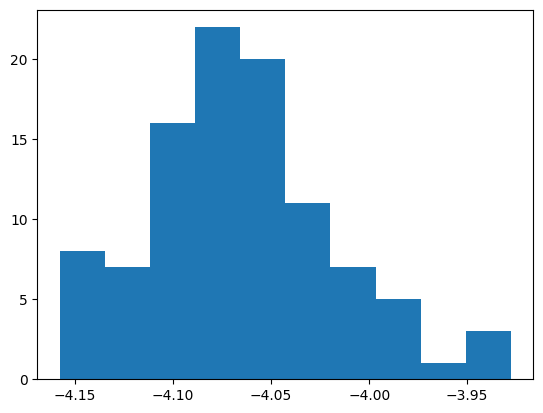

In [107]:
plt.hist(out)

In [100]:
len(res.x)

24

In [70]:
estim = StatevectorEstimator()
result = estim.run([(qc_final, Ham)])

In [80]:
result.result()[0].data.evs

array(-4.20267211)

In [27]:
from qiskit.transpiler import generate_preset_pass_manager

In [76]:

pm = generate_preset_pass_manager(optimization_level = 2, backend = queb)
isa_qc = pm.run(qc_final)
isa_obs = Ham.apply_layout(isa_qc.layout)

In [78]:
isa_obs

SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIYZYIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIXZXIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIYZZZYIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIXZZZXIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIYIIIIIIIIIIZIIIIIIIIYIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIXIIIIIIIIIIZIIIIIIIIXIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIIIIIIIIIII

In [83]:
from qiskit_ibm_runtime import Session, EstimatorOptions, EstimatorV2
hist_raw = []
hist_trex = []
hist_full = []
options_raw = EstimatorOptions()
options_raw.default_shots = 9000/9
options_raw.resilience_level = 0
options_trex = EstimatorOptions()
options_trex.default_shots = 9000/9
options_trex.resilience_level = 1
options_full = EstimatorOptions()
options_full.default_shots = 9000/9
options_full.resilience_level = 2
with Session(backend = queb) as session:
    estim_raw = EstimatorV2(session, options = options_raw)
    estim_trex = EstimatorV2(session, options = options_trex)
    estim_full = EstimatorV2(session, options = options_full)
    for i in range(100):
        res_raw = estim_raw.run([(isa_qc, isa_obs)])
        res_trex = estim_trex.run([(isa_qc, isa_obs)])
        res_full = estim_full.run([(isa_qc, isa_obs)])
        hist_raw.append(res_raw.result()[0].data.evs)
        hist_trex.append(res_trex.result()[0].data.evs)
        hist_full.append(res_full.result()[0].data.evs)

In [32]:
from qiskit_ibm_runtime import Session, EstimatorOptions, EstimatorV2

In [33]:
import matplotlib.pyplot as plt 

(array([ 2.,  8.,  8., 13., 17., 21., 11., 11.,  6.,  3.]),
 array([-3.529 , -3.5015, -3.474 , -3.4465, -3.419 , -3.3915, -3.364 ,
        -3.3365, -3.309 , -3.2815, -3.254 ]),
 <BarContainer object of 10 artists>)

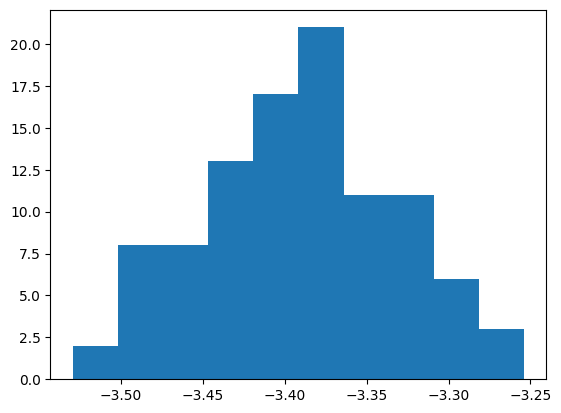

In [89]:
plt.hist(hist_raw, 10)

(array([ 3.,  9.,  6., 16., 18., 19.,  8.,  7.,  7.,  7.]),
 array([-3.56491007, -3.53750597, -3.51010186, -3.48269776, -3.45529366,
        -3.42788956, -3.40048546, -3.37308136, -3.34567726, -3.31827316,
        -3.29086906]),
 <BarContainer object of 10 artists>)

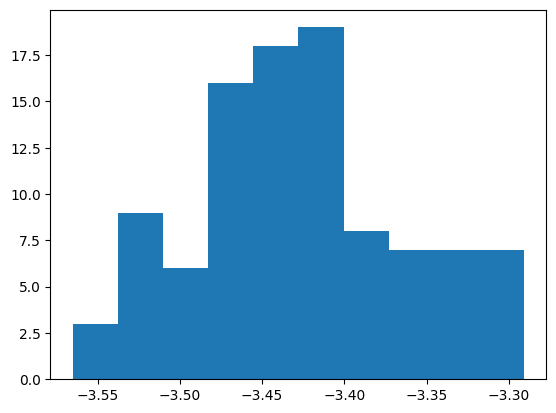

In [90]:
plt.hist(hist_trex, 10)

(array([ 1.,  1.,  8., 17., 12., 17., 27., 11.,  3.,  3.]),
 array([-3.78303593, -3.73180291, -3.68056989, -3.62933687, -3.57810384,
        -3.52687082, -3.4756378 , -3.42440478, -3.37317175, -3.32193873,
        -3.27070571]),
 <BarContainer object of 10 artists>)

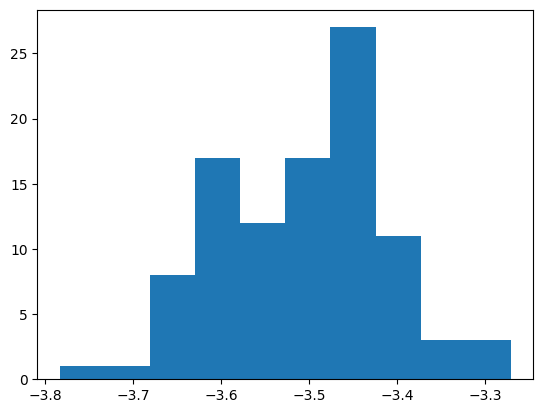

In [91]:
plt.hist(hist_full, 10)

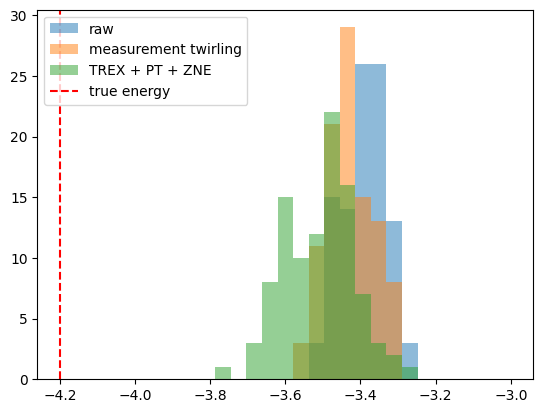

In [98]:
bins = np.linspace(-4.2, -3, 30)

plt.hist(hist_raw, bins, alpha=0.5, label='raw')
plt.hist(hist_trex, bins, alpha=0.5, label='measurement twirling')
plt.hist(hist_full, bins, alpha=0.5, label='TREX + PT + ZNE')
plt.axvline(x=-4.2, color='r', linestyle='--', label = 'true energy')
plt.legend(loc='upper left')
plt.show()

In [171]:
Ham

SparsePauliOp(['IIIIIYZY', 'IIIIIXZX', 'IIIYZZZY', 'IIIXZZZX', 'IYZYIIII', 'IXZXIIII', 'IYZZZYII', 'IXZZZXII', 'IIIIYZYI', 'IIIIXZXI', 'IIYZZZYI', 'IIXZZZXI', 'YZYIIIII', 'XZXIIIII', 'YZZZYIII', 'XZZZXIII', 'IIIIIIZI', 'IIIIIIIZ', 'IIIIIIZZ', 'IIIIZIII', 'IIIIIZII', 'IIIIZZII', 'IIZIIIII', 'IIIZIIII', 'IIZZIIII', 'ZIIIIIII', 'IZIIIIII', 'ZZIIIIII'],
              coeffs=[-0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j,
 -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j,
 -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j,  0.5+0.j, -0.5+0.j, -0.5+0.j,
  0.5+0.j, -0.5+0.j, -0.5+0.j,  0.5+0.j, -0.5+0.j, -0.5+0.j,  0.5+0.j])

In [23]:
from qiskit.circuit import ParameterVector
custom_ansatz = QuantumCircuit(8)
theta = ParameterVector('theta', 24)
for i in range(8):
    custom_ansatz.rx(theta[2*i], i)
    custom_ansatz.rz(theta[2*i + 1], i)
for i in range(4):
    custom_ansatz.cz(2*i, 2*i+1)
for i in range(3):
    custom_ansatz.cz(2*i + 1, 2*i + 2)
for i in range(8):
    custom_ansatz.rx(theta[16 + i], i)
custom_ansatz.draw()

┌──────────────┐ ┌──────────────┐   ┌───────────────┐                 
q_0: ─┤ Rx(theta[0]) ├─┤ Rz(theta[1]) ├─■─┤ Rx(theta[16]) ├─────────────────
      ├──────────────┤ ├──────────────┤ │ └───────────────┘┌───────────────┐
q_1: ─┤ Rx(theta[2]) ├─┤ Rz(theta[3]) ├─■─────────■────────┤ Rx(theta[17]) ├
      ├──────────────┤ ├──────────────┤           │        ├───────────────┤
q_2: ─┤ Rx(theta[4]) ├─┤ Rz(theta[5]) ├─■─────────■────────┤ Rx(theta[18]) ├
      ├──────────────┤ ├──────────────┤ │                  ├───────────────┤
q_3: ─┤ Rx(theta[6]) ├─┤ Rz(theta[7]) ├─■─────────■────────┤ Rx(theta[19]) ├
      ├──────────────┤ ├──────────────┤           │        ├───────────────┤
q_4: ─┤ Rx(theta[8]) ├─┤ Rz(theta[9]) ├─■─────────■────────┤ Rx(theta[20]) ├
     ┌┴──────────────┤┌┴──────────────┤ │                  ├───────────────┤
q_5: ┤ Rx(theta[10]) ├┤ Rz(theta[11]) ├─■─────────■────────┤ Rx(theta[21]) ├
     ├───────────────┤├───────────────┤           │        ├───────────────┤
q_6: ┤ Rx(theta[12]) ├┤ Rz(theta[13]) ├─■─────────■────────┤ Rx(theta[22]) ├
     ├───────────────┤├───────────────┤ │ ┌───────────────┐└───────────────┘
q_7: ┤ Rx(theta[14]) ├┤ Rz(theta[15]) ├─■─┤ Rx(theta[23]) ├─────────────────
     └───────────────┘└───────────────┘   └───────────────┘

In [20]:
n_params = custom_ansatz.num_parameters
res_test = minimize(lambda x: cost(custom_ansatz, Ham, x), np.random.rand(n_params), method = 'COBYLA', bounds = [(0, 2*np.pi)] * n_params, options = {'maxiter' : 100000})

In [21]:
res_test

 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -3.5275724755239692
       x: [ 3.840e-01  1.002e-04 ...  8.663e-02  1.054e+00]
    nfev: 2460
   maxcv: 2.696915497486172e-20

In [22]:
qc_final_short = custom_ansatz.assign_parameters(res_test.x)

In [23]:
qc_final_short.draw()

┌───────────┐ ┌────────────────┐   ┌───────────┐                
q_0: ─┤ Rx(0.384) ├─┤ Rz(0.00010024) ├─■─┤ Rx(1.054) ├────────────────
     ┌┴───────────┴┐├────────────────┤ │ └───────────┘┌──────────────┐
q_1: ┤ Rx(0.75323) ├┤ Rz(0.00020438) ├─■───────■──────┤ Rx(0.086689) ├
     └┬────────────┤├────────────────┤         │      └──┬───────┬───┘
q_2: ─┤ Rx(1.1908) ├┤ Rz(1.3227e-05) ├─■───────■─────────┤ Rx(0) ├────
     ┌┴────────────┤└┬──────────────┬┘ │              ┌──┴───────┴──┐ 
q_3: ┤ Rx(0.15712) ├─┤ Rz(0.001768) ├──■───────■──────┤ Rx(0.47938) ├─
     ├─────────────┤┌┴──────────────┴┐         │      ├─────────────┤ 
q_4: ┤ Rx(0.15703) ├┤ Rz(0.00048463) ├─■───────■──────┤ Rx(0.47923) ├─
     └┬────────────┤├────────────────┤ │              └──┬───────┬──┘ 
q_5: ─┤ Rx(1.1909) ├┤ Rz(2.4397e-06) ├─■───────■─────────┤ Rx(0) ├────
     ┌┴────────────┤├────────────────┤         │      ┌──┴───────┴──┐ 
q_6: ┤ Rx(0.75308) ├┤ Rz(0.00016798) ├─■───────■──────┤ Rx(0.08663) ├─
     ├─────────────┤└───┬───────┬────┘ │ ┌───────────┐└─────────────┘ 
q_7: ┤ Rx(0.38405) ├────┤ Rz(0) ├──────■─┤ Rx(1.054) ├────────────────
     └─────────────┘    └───────┘        └───────────┘

In [16]:
Ham = HamiltonianLoader().load_hub_square_U2()

In [17]:
Ham

SparsePauliOp(['IIIIIYZY', 'IIIIIXZX', 'IIIYZZZY', 'IIIXZZZX', 'IYZYIIII', 'IXZXIIII', 'IYZZZYII', 'IXZZZXII', 'IIIIYZYI', 'IIIIXZXI', 'IIYZZZYI', 'IIXZZZXI', 'YZYIIIII', 'XZXIIIII', 'YZZZYIII', 'XZZZXIII', 'IIIIIIZI', 'IIIIIIIZ', 'IIIIIIZZ', 'IIIIZIII', 'IIIIIZII', 'IIIIZZII', 'IIZIIIII', 'IIIZIIII', 'IIZZIIII', 'ZIIIIIII', 'IZIIIIII', 'ZZIIIIII'],
              coeffs=[-0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j,
 -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j,
 -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j,  0.5+0.j, -0.5+0.j, -0.5+0.j,
  0.5+0.j, -0.5+0.j, -0.5+0.j,  0.5+0.j, -0.5+0.j, -0.5+0.j,  0.5+0.j])

In [24]:
test = sv_estim.run([(qc_final_short, Ham)])

In [25]:
test.result()[0].data.evs

array(-3.52757248)

In [28]:
res_test.x

array([ 3.83997831e-01,  1.00240740e-04,  7.53225813e-01,  2.04375783e-04,
        1.19081583e+00,  1.32265803e-05,  1.57117741e-01,  1.76796837e-03,
        1.57033269e-01,  4.84630113e-04,  1.19088668e+00,  2.43974551e-06,
        7.53080019e-01,  1.67981696e-04,  3.84051508e-01, -2.69691550e-20,
        1.05396922e+00,  8.66888314e-02, -2.67174854e-20,  4.79379735e-01,
        4.79229296e-01, -2.67418676e-20,  8.66300478e-02,  1.05401347e+00])

In [25]:
params = np.array([ 3.83997831e-01,  1.00240740e-04,  7.53225813e-01,  2.04375783e-04,
        1.19081583e+00,  1.32265803e-05,  1.57117741e-01,  1.76796837e-03,
        1.57033269e-01,  4.84630113e-04,  1.19088668e+00,  2.43974551e-06,
        7.53080019e-01,  1.67981696e-04,  3.84051508e-01, -2.69691550e-20,
        1.05396922e+00,  8.66888314e-02, -2.67174854e-20,  4.79379735e-01,
        4.79229296e-01, -2.67418676e-20,  8.66300478e-02,  1.05401347e+00])

qc_final_short = custom_ansatz.assign_parameters(params)

In [30]:
import pickle
with open('hub_res.pkl', 'rb') as file:
    test = pickle.load(file)
test.x

array([ 1.54309543e+00,  3.24226334e-03,  3.77742214e-01,  3.76717866e-01,
       -8.63666953e-23,  1.59959515e+00,  0.00000000e+00, -3.18818037e-21,
        2.57358960e+00,  2.58217570e+00,  3.13685919e+00,  3.14131220e+00,
        3.14386697e+00,  1.60402290e-01,  1.63787018e-01,  2.13950649e-05,
        7.93789275e-05, -4.44692297e-21,  5.78097719e-22,  8.34026585e-21,
        3.38813179e-21,  5.79355329e-05,  3.84179396e-05,  0.00000000e+00])

In [28]:
pm = generate_preset_pass_manager(optimization_level = 2, backend = queb)
isa_qc_short = pm.run(qc_final_short)
isa_obs_short = Ham.apply_layout(isa_qc_short.layout)

In [34]:
hist_raw_short = []
hist_trex_short = []
hist_full_short = []
options_raw = EstimatorOptions()
options_raw.default_shots = 9000/9
options_raw.resilience_level = 0
options_trex = EstimatorOptions()
options_trex.default_shots = 9000/9
options_trex.resilience_level = 1
options_full = EstimatorOptions()
options_full.default_shots = 9000/9
options_full.resilience_level = 2
with Session(backend = queb) as session:
    estim_raw = EstimatorV2(session, options = options_raw)
    estim_trex = EstimatorV2(session, options = options_trex)
    estim_full = EstimatorV2(session, options = options_full)
    for i in range(100):
        res_raw = estim_raw.run([(isa_qc_short, isa_obs_short)])
        res_trex = estim_trex.run([(isa_qc_short, isa_obs_short)])
        res_full = estim_full.run([(isa_qc_short, isa_obs_short)])
        hist_raw_short.append(res_raw.result()[0].data.evs)
        hist_trex_short.append(res_trex.result()[0].data.evs)
        hist_full_short.append(res_full.result()[0].data.evs)

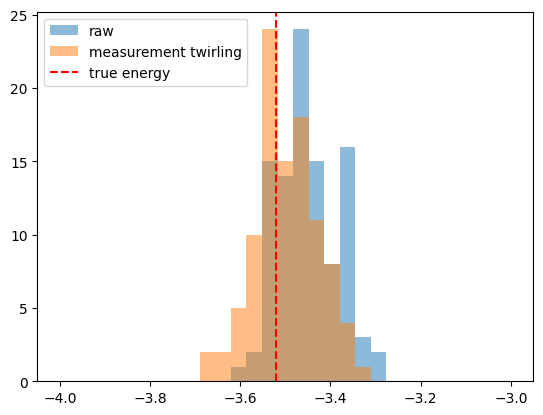

In [39]:
bins = np.linspace(-4, -3, 30)

plt.hist(hist_raw_short, bins, alpha=0.5, label='raw')
plt.hist(hist_trex_short, bins, alpha=0.5, label='measurement twirling')
#plt.hist(hist_full_short, bins, alpha=0.5, label='TREX + PT + ZNE')
plt.axvline(x=-3.52, color='r', linestyle='--', label = 'true energy')
plt.legend(loc='upper left')
plt.show()

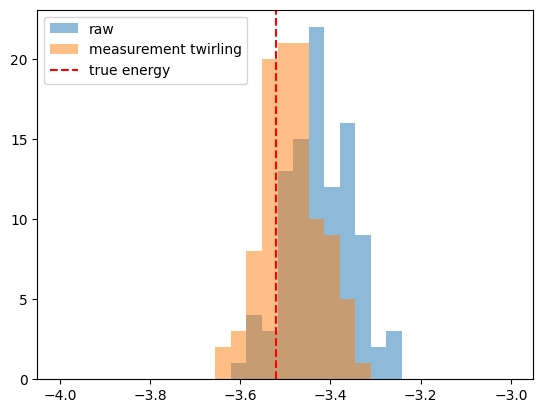

In [35]:
bins = np.linspace(-4, -3, 30)

plt.hist(hist_raw_short, bins, alpha=0.5, label='raw')
plt.hist(hist_trex_short, bins, alpha=0.5, label='measurement twirling')
#plt.hist(hist_full_short, bins, alpha=0.5, label='TREX + PT + ZNE')
plt.axvline(x=-3.52, color='r', linestyle='--', label = 'true energy')
plt.legend(loc='upper left')
plt.show()

In [203]:
hist_raw_short

[array(-1.896),
 array(-1.9795),
 array(-1.9865),
 array(-1.9695),
 array(-1.952),
 array(-1.89),
 array(-1.9025),
 array(-1.951),
 array(-1.9675),
 array(-1.9025),
 array(-2.01),
 array(-2.039),
 array(-2.0735),
 array(-2.019),
 array(-1.9315),
 array(-1.8815),
 array(-1.926),
 array(-1.9325),
 array(-1.9475),
 array(-2.0295),
 array(-1.8495),
 array(-2.0065),
 array(-1.9115),
 array(-1.9415),
 array(-1.996),
 array(-1.9975),
 array(-1.9525),
 array(-2.0305),
 array(-1.9565),
 array(-2.0125),
 array(-1.9975),
 array(-2.0055),
 array(-2.033),
 array(-1.913),
 array(-1.9785),
 array(-1.8295),
 array(-1.9755),
 array(-1.987),
 array(-1.9375),
 array(-2.0235),
 array(-1.9255),
 array(-1.93),
 array(-1.947),
 array(-1.8965),
 array(-1.974),
 array(-1.95),
 array(-1.965),
 array(-1.993),
 array(-1.931),
 array(-1.9925),
 array(-1.977),
 array(-1.9945),
 array(-1.971),
 array(-2.089),
 array(-1.9115),
 array(-2.0155),
 array(-1.987),
 array(-2.048),
 array(-1.9215),
 array(-1.936),
 array(-2

In [146]:
res_raw.result()

PrimitiveResult([PubResult(data=DataBin(evs=np.ndarray(<shape=(), dtype=float64>), stds=np.ndarray(<shape=(), dtype=float64>), ensemble_standard_error=np.ndarray(<shape=(), dtype=float64>)), metadata={'shots': 1000, 'target_precision': 0.03162277660168379, 'circuit_metadata': {}, 'num_randomizations': 1})], metadata={'dynamical_decoupling': {'enable': False, 'sequence_type': 'XX', 'extra_slack_distribution': 'middle', 'scheduling_method': 'alap'}, 'twirling': {'enable_gates': False, 'enable_measure': False, 'num_randomizations': 'auto', 'shots_per_randomization': 'auto', 'interleave_randomizations': True, 'strategy': 'active-accum'}, 'resilience': {'measure_mitigation': False, 'zne_mitigation': False, 'pec_mitigation': False}, 'version': 2})

In [149]:
len(Ham.group_commuting(qubit_wise=True))

9

In [150]:
Ham.group_commuting(qubit_wise=True)

[SparsePauliOp(['IYZZZYII', 'IIIIIYZY', 'IIZZIIII', 'IIIIIIZI', 'IIIIZIII', 'IIZIIIII', 'IIIZIIII', 'ZIIIIIII'],
               coeffs=[-0.5+0.j, -0.5+0.j,  0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j,
  -0.5+0.j]),
 SparsePauliOp(['IXZZZXII', 'IIIIIXZX'],
               coeffs=[-0.5+0.j, -0.5+0.j]),
 SparsePauliOp(['IIYZZZYI', 'YZYIIIII', 'IIIIZZII', 'IIIIIIIZ', 'IIIIIZII', 'IZIIIIII'],
               coeffs=[-0.5+0.j, -0.5+0.j,  0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j]),
 SparsePauliOp(['IIXZZZXI', 'XZXIIIII'],
               coeffs=[-0.5+0.j, -0.5+0.j]),
 SparsePauliOp(['IIIYZZZY', 'IYZYIIII'],
               coeffs=[-0.5+0.j, -0.5+0.j]),
 SparsePauliOp(['IIIXZZZX', 'IXZXIIII'],
               coeffs=[-0.5+0.j, -0.5+0.j]),
 SparsePauliOp(['YZZZYIII', 'IIIIYZYI'],
               coeffs=[-0.5+0.j, -0.5+0.j]),
 SparsePauliOp(['XZZZXIII', 'IIIIXZXI'],
               coeffs=[-0.5+0.j, -0.5+0.j]),
 SparsePauliOp(['IIIIIIZZ', 'ZZIIIIII'],
               coeffs=[0.5+0.j, 0.5+0.j])]

In [37]:
from state_preparation import StatePreparator
state_prep = StatePreparator()
state = state_prep.load_ground_state_hub_2x2_U2()
state.draw()

┌────────────┐                                                     »
q_0: ──┤ Ry(1.5431) ├─────────────────────────────────────────────────────»
     ┌─┴────────────┴┐                                                    »
q_1: ┤ Ry(0.0032423) ├────────────────────────────────────────────────────»
     └┬─────────────┬┘                                                    »
q_2: ─┤ Ry(0.37774) ├─────────────────────────────────────────────────────»
      ├─────────────┤                                                     »
q_3: ─┤ Ry(0.37672) ├─────────────────────────────────────────────■───────»
      └──┬───────┬──┘                                           ┌─┴─┐     »
q_4: ────┤ Ry(0) ├──────────────────────────────────■───────────┤ X ├─────»
       ┌─┴───────┴──┐                             ┌─┴─┐     ┌───┴───┴────┐»
q_5: ──┤ Ry(1.5996) ├──────────────■──────────────┤ X ├─────┤ Ry(0.1604) ├»
       └─┬───────┬──┘            ┌─┴─┐       ┌────┴───┴────┐└────────────┘»
q_6: ────┤ Ry(0) ├──────■────────┤ X ├───────┤ Ry(0.16379) ├──────■───────»
         ├───────┤    ┌─┴─┐┌─────┴───┴──────┐└─────────────┘    ┌─┴─┐     »
q_7: ────┤ Ry(0) ├────┤ X ├┤ Ry(2.1395e-05) ├───────────────────┤ X ├─────»
         └───────┘    └───┘└────────────────┘                   └───┘     »
«                                                       ┌────────────┐         »
«q_0: ────────────────────────────────────────■─────────┤ Ry(2.5736) ├─────────»
«                                           ┌─┴─┐       ├────────────┤         »
«q_1: ──────────────────────■───────────────┤ X ├───────┤ Ry(2.5822) ├────■────»
«                         ┌─┴─┐         ┌───┴───┴────┐  └────────────┘  ┌─┴─┐  »
«q_2: ──────■─────────────┤ X ├─────────┤ Ry(3.1369) ├────────■─────────┤ X ├──»
«         ┌─┴─┐       ┌───┴───┴────┐    └────────────┘      ┌─┴─┐     ┌─┴───┴─┐»
«q_3: ────┤ X ├───────┤ Ry(3.1413) ├──────────■─────────────┤ X ├─────┤ Ry(0) ├»
«     ┌───┴───┴────┐  └────────────┘        ┌─┴─┐         ┌─┴───┴─┐   └───────┘»
«q_4: ┤ Ry(3.1439) ├────────■───────────────┤ X ├─────────┤ Ry(0) ├────────────»
«     └────────────┘      ┌─┴─┐       ┌─────┴───┴──────┐  └───────┘            »
«q_5: ──────■─────────────┤ X ├───────┤ Ry(5.7936e-05) ├───────────────────────»
«         ┌─┴─┐     ┌─────┴───┴──────┐└────────────────┘                       »
«q_6: ────┤ X ├─────┤ Ry(3.8418e-05) ├─────────────────────────────────────────»
«       ┌─┴───┴─┐   └────────────────┘                                         »
«q_7: ──┤ Ry(0) ├──────────────────────────────────────────────────────────────»
«       └───────┘                                                              »
«              ┌────────────────┐
«q_0: ────■────┤ Ry(7.9379e-05) ├
«       ┌─┴─┐  └───┬───────┬────┘
«q_1: ──┤ X ├──────┤ Ry(0) ├─────
«     ┌─┴───┴─┐    └───────┘     
«q_2: ┤ Ry(0) ├──────────────────
«     └───────┘                  
«q_3: ───────────────────────────
«                                
«q_4: ───────────────────────────
«                                
«q_5: ───────────────────────────
«                                
«q_6: ───────────────────────────
«                                
«q_7: ───────────────────────────
«

In [38]:
qc_final_short.draw()

┌───────────┐ ┌────────────────┐   ┌───────────┐                
q_0: ─┤ Rx(0.384) ├─┤ Rz(0.00010024) ├─■─┤ Rx(1.054) ├────────────────
     ┌┴───────────┴┐├────────────────┤ │ └───────────┘┌──────────────┐
q_1: ┤ Rx(0.75323) ├┤ Rz(0.00020438) ├─■───────■──────┤ Rx(0.086689) ├
     └┬────────────┤├────────────────┤         │      └──┬───────┬───┘
q_2: ─┤ Rx(1.1908) ├┤ Rz(1.3227e-05) ├─■───────■─────────┤ Rx(0) ├────
     ┌┴────────────┤└┬──────────────┬┘ │              ┌──┴───────┴──┐ 
q_3: ┤ Rx(0.15712) ├─┤ Rz(0.001768) ├──■───────■──────┤ Rx(0.47938) ├─
     ├─────────────┤┌┴──────────────┴┐         │      ├─────────────┤ 
q_4: ┤ Rx(0.15703) ├┤ Rz(0.00048463) ├─■───────■──────┤ Rx(0.47923) ├─
     └┬────────────┤├────────────────┤ │              └──┬───────┬──┘ 
q_5: ─┤ Rx(1.1909) ├┤ Rz(2.4397e-06) ├─■───────■─────────┤ Rx(0) ├────
     ┌┴────────────┤├────────────────┤         │      ┌──┴───────┴──┐ 
q_6: ┤ Rx(0.75308) ├┤ Rz(0.00016798) ├─■───────■──────┤ Rx(0.08663) ├─
     ├─────────────┤└───┬───────┬────┘ │ ┌───────────┐└─────────────┘ 
q_7: ┤ Rx(0.38405) ├────┤ Rz(0) ├──────■─┤ Rx(1.054) ├────────────────
     └─────────────┘    └───────┘        └───────────┘

In [40]:
with open('hub_res.pkl', 'wb') as file:
    pickle.dump(qc_final_short, file)